# Steppable-Surface Segmentation of a Simulated LiDAR Staircase

End-to-end mini-project notebook:

1. Generate a 4-step staircase point cloud from mathematical equations
2. Segment steppable treads vs. risers vs. other with four geometric methods
3. Visualize before/after in 3D
4. Compute steppable-class metrics (Accuracy, Precision, Recall, F1, IoU)
5. Analyse the effect of noise and outliers
6. Discuss robot-safety implications

Dependencies: `numpy`, `scikit-learn`, `matplotlib` (Open3D optional).

## 0. Setup

In [1]:
import sys, os
# Make `src` importable whether run from notebooks/ or repo root.
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".." if os.path.basename(os.getcwd()) == "notebooks" else "."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import matplotlib.pyplot as plt

from src.config import StaircaseConfig, SegmentationParams, LABEL_NAMES, LABEL_COLORS, STEPPABLE, RISER, OTHER
from src.data_generation import generate_staircase
from src.segmentation import METHODS, segment_by_normals
from src.evaluation import steppable_metrics, confusion_matrix, evaluate_methods, noise_sweep
from src.visualization import plot_pointcloud_mpl

np.set_printoptions(precision=3, suppress=True)
print("Methods available:", list(METHODS))

Methods available: ['normals', 'ransac', 'dbscan_slope', 'height_histogram']


## 1. Data generation

For step $i = 0..3$, with width $w$, depth $d$, height $h$:

**Tread (steppable):**
$$x \sim \mathcal{U}(0,w),\quad y \sim \mathcal{U}(i d,(i{+}1)d),\quad z = i h + \epsilon_z,\ \epsilon_z\sim\mathcal{N}(0,0.02^2)$$

**Riser (vertical):**
$$x \sim \mathcal{U}(0,w),\quad y = i d + \epsilon_y,\quad z \sim \mathcal{U}((i{-}1)h, i h)$$

Plus isotropic LiDAR noise, uniform outliers, and edge clutter.

In [2]:
cfg = StaircaseConfig()
points, gt = generate_staircase(cfg)
print(f"{len(points)} points")
for lbl in (STEPPABLE, RISER, OTHER):
    print(f"  {LABEL_NAMES[lbl]:>9}: {(gt==lbl).sum()}")

18270 points
  steppable: 12000
      riser: 5400
      other: 870


### 1.1 Visualize the raw cloud (ground truth)

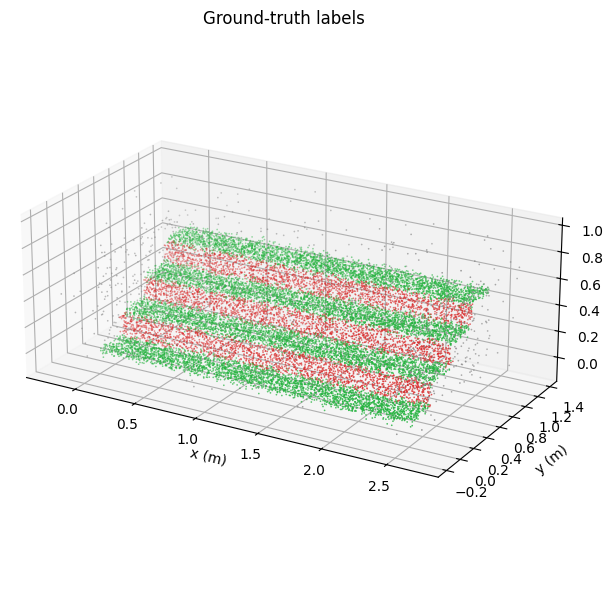

In [3]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
plot_pointcloud_mpl(points, gt, title="Ground-truth labels", ax=ax)
plt.tight_layout(); plt.show()

## 2. Segmentation

Four geometric methods, all returning a per-point label in {steppable, riser, other}.

In [4]:
params = SegmentationParams()
pred_normals = segment_by_normals(points, params)
m = steppable_metrics(gt, pred_normals)
print("PCA-normal method, steppable metrics:")
print(m)

PCA-normal method, steppable metrics:
Metrics(accuracy=0.7943076081007115, precision=0.9662231320368475, recall=0.8653333333333333, f1=0.9129995164197476, iou=0.8399255844050797)


### 2.1 Run and compare all four methods

In [5]:
results = evaluate_methods(points, gt, METHODS, params)
print(f"{'method':<18}{'acc':>7}{'P':>8}{'R':>8}{'F1':>8}{'IoU':>8}")
for name, mt in results.items():
    print(f"{name:<18}{mt.accuracy:>7.3f}{mt.precision:>8.3f}{mt.recall:>8.3f}{mt.f1:>8.3f}{mt.iou:>8.3f}")
best = max(results, key=lambda k: results[k].f1)
print("\nBest by F1:", best)

method                acc       P       R      F1     IoU
normals             0.794   0.966   0.865   0.913   0.840
ransac              0.711   0.888   0.701   0.784   0.644
dbscan_slope        0.769   0.977   0.796   0.877   0.782
height_histogram    0.722   0.975   0.818   0.889   0.801

Best by F1: normals


### 2.2 Before / after visualization (best method)

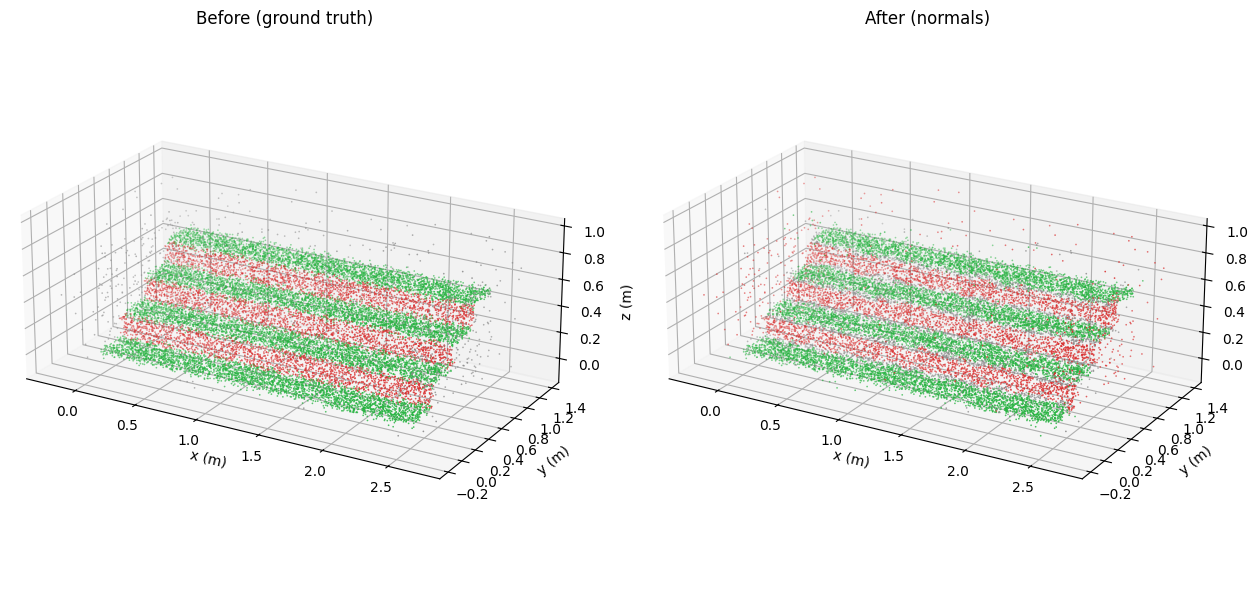

In [6]:
pred_best = METHODS[best](points, params)
fig = plt.figure(figsize=(13, 6))
ax1 = fig.add_subplot(121, projection="3d")
plot_pointcloud_mpl(points, gt, title="Before (ground truth)", ax=ax1)
ax2 = fig.add_subplot(122, projection="3d")
plot_pointcloud_mpl(points, pred_best, title=f"After ({best})", ax=ax2)
plt.tight_layout(); plt.show()

### 2.3 Confusion matrix (best method)

rows = ground truth, cols = prediction, order [steppable, riser, other]
[[10384   239  1377]
 [  212  3961  1227]
 [  151   552   167]]


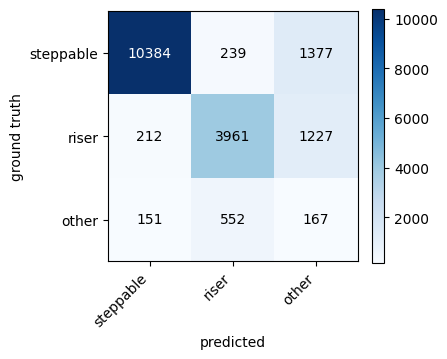

In [7]:
cm = confusion_matrix(gt, pred_best)
print("rows = ground truth, cols = prediction, order [steppable, riser, other]")
print(cm)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels([LABEL_NAMES[i] for i in range(3)], rotation=45, ha="right")
ax.set_yticklabels([LABEL_NAMES[i] for i in range(3)])
ax.set_xlabel("predicted"); ax.set_ylabel("ground truth")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

## 3. Noise and outlier sensitivity

We sweep the LiDAR noise $\sigma_L$ and the outlier ratio $\rho$, re-generating the
cloud each time, and record steppable F1 for the best method.

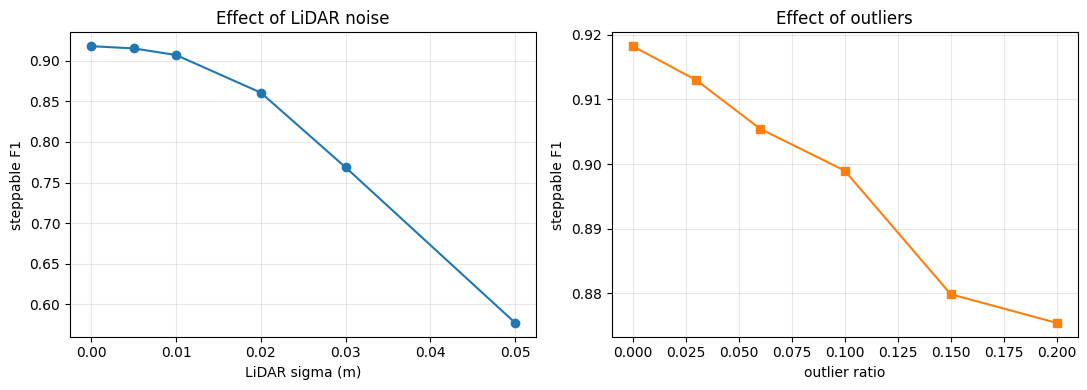

LiDAR sweep (sigma, F1): [(0.0, 0.918), (0.005, 0.915), (0.01, 0.907), (0.02, 0.861), (0.03, 0.769), (0.05, 0.577)]
Outlier sweep (rho, F1): [(0.0, 0.918), (0.03, 0.913), (0.06, 0.905), (0.1, 0.899), (0.15, 0.88), (0.2, 0.875)]


In [8]:
sigmas = [0.0, 0.005, 0.01, 0.02, 0.03, 0.05]
outlier_ratios = [0.0, 0.03, 0.06, 0.10, 0.15, 0.20]
sweep = noise_sweep(METHODS[best], sigmas, outlier_ratios, base_cfg=cfg, params=params)
lid = np.array(sweep["lidar_sigma"]); out = np.array(sweep["outlier_ratio"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(lid[:, 0], lid[:, 1], "o-"); axes[0].set_xlabel("LiDAR sigma (m)")
axes[0].set_ylabel("steppable F1"); axes[0].set_title("Effect of LiDAR noise"); axes[0].grid(alpha=.3)
axes[1].plot(out[:, 0], out[:, 1], "s-", color="C1"); axes[1].set_xlabel("outlier ratio")
axes[1].set_ylabel("steppable F1"); axes[1].set_title("Effect of outliers"); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print("LiDAR sweep (sigma, F1):", [(round(s,3), round(f,3)) for s,f in sweep["lidar_sigma"]])
print("Outlier sweep (rho, F1):", [(round(s,3), round(f,3)) for s,f in sweep["outlier_ratio"]])

## 4. Discussion: is this safe for a stair-following robot?

For foot placement the error cost is **asymmetric** — stepping where there is no
tread is dangerous, skipping a valid tread is not. The decisive metric is therefore
**steppable precision**, not raw accuracy.

- The PCA-normal method gives the best F1/IoU and recall — it finds nearly all
  treads — but is the most noise-sensitive because per-point normals inherit the
  full surface jitter.
- DBSCAN and the height-histogram reach the **highest steppable precision
  (~0.98)**: a robot acting on their output would almost never be told to step on
  a non-tread, at the price of discarding some valid footholds.
- Outliers are tolerated well; **LiDAR noise is the binding constraint**. Beyond
  ~0.05 m a single geometric pass is insufficient and temporal fusion or a learned
  refinement stage would be needed.

**Verdict:** at clean-to-moderate noise, a precision-oriented geometric method,
combined with a planner that only commits to high-confidence, spatially consistent
treads, is a reasonable basis for a cautious stair-climbing controller.

## 5. (Optional) Interactive 3D with Open3D

If `open3d` is installed, this opens an interactive window (skipped in headless
environments).

In [9]:
try:
    from src.visualization import show_open3d
    show_open3d(points, pred_best)
except Exception as e:
    print("Open3D view skipped:", e)

Open3D view skipped: Install open3d for interactive visualisation: pip install open3d
